In [45]:
import os
from pathlib import Path
from typing import Annotated, Sequence, TypedDict

from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages  # reducer：控制节点更新如何与现有状态合并
from langgraph.prebuilt import ToolNode

env_path = Path(".env")
if not env_path.exists():
    env_path = Path("langgraph_quickstart/.env")

load_dotenv(env_path)


True

In [46]:
# email = Annotated[str,"这是一个有效的电子邮件地址"]
# Sequence是用来表示消息序列的类型

class AgentState(TypedDict):
    #消息序列是messages的类型
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
@tool
def add(a: int, b: int) -> int:
    """Returns the sum of a and b."""
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Returns the difference of a and b."""
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """Returns the product of a and b."""
    return a * b

tools =[add, subtract, multiply]

model = ChatOpenAI(
    model="gpt-4o",
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    openai_api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai-proxy.org/v1"),
    ).bind_tools(tools)  #记得完成工具绑定


In [48]:
def model_call(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content="你是我的AI助手，请回答我的下列问题")
    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}


In [49]:
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    return "continue"


In [50]:
graph = StateGraph(AgentState)

graph.add_node("our_agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)
graph.add_edge("tools", "our_agent")

app = graph.compile()


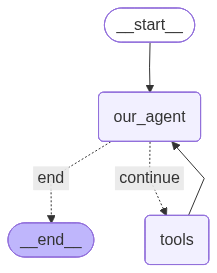

In [51]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [52]:
def print_stream(stream):
    for chunk in stream:
        # stream_mode="values" 会直接返回 state；其它模式可能返回 {node_name: state_update}
        if "messages" in chunk:
            messages = chunk["messages"]
        else:
            node_update = next(iter(chunk.values()))
            messages = node_update.get("messages", [])

        if not messages:
            continue

        message = messages[-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


In [55]:
inputs = {"messages": [("user", "请计算一下100+23，3-20,20*40的结果，然后告诉三个数的和是多少")]}

print_stream(app.stream(inputs, stream_mode="values"))


================================ Human Message =================================

请计算一下100+23，3-20,20*40的结果，然后告诉三个数的和是多少
================================== Ai Message ==================================
Tool Calls:
  add (call_Fi0vhpWnRCWtRLxrcfMhla0p)
 Call ID: call_Fi0vhpWnRCWtRLxrcfMhla0p
  Args:
    a: 100
    b: 23
  subtract (call_COm8fcbhU1xRuoRwVXeQG5Ke)
 Call ID: call_COm8fcbhU1xRuoRwVXeQG5Ke
  Args:
    a: 3
    b: 20
  multiply (call_L87XqIgrRdw43woGKI1ioDbQ)
 Call ID: call_L87XqIgrRdw43woGKI1ioDbQ
  Args:
    a: 20
    b: 40
================================= Tool Message =================================
Name: multiply

800
================================== Ai Message ==================================
Tool Calls:
  add (call_wzQZf06ff6BCtChm9AeqzM6j)
 Call ID: call_wzQZf06ff6BCtChm9AeqzM6j
  Args:
    a: 123
    b: -17
================================= Tool Message =================================
Name: add

106
================================== Ai Message ==============